# K-Nearest Neighbors (KNN) Model Training

This notebook implements and evaluates the KNN classifier for forest fire prediction.

**Objectives:**
1. Find optimal k value using sklearn KNN on engineered features
2. Compare custom KNN implementation on original vs engineered datasets
3. Evaluate performance metrics: accuracy, precision, recall, F1-score

## 1. Import Libraries

In [1]:
# Add project root to path and import config
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from config import FIRES_ENGINEERED_SUPERVISED, FIRES_MERGED_SUPERVISED, MODELS_DIR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Import custom KNN model
from models.knn import KNN

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load Datasets

In [2]:
# Load engineered features dataset (already scaled and selected)
df_engineered = pd.read_csv(FIRES_ENGINEERED_SUPERVISED)
print(f"📊 Engineered Dataset: {df_engineered.shape}")
print(f"   Features: {df_engineered.shape[1] - 3} (excluding lon, lat, class)")
print(f"   Class distribution:\n{df_engineered['class'].value_counts()}")

# Load original merged features dataset (all features)
df_original = pd.read_csv(FIRES_MERGED_SUPERVISED)
print(f"\n📊 Original Dataset: {df_original.shape}")
print(f"   Features: {df_original.shape[1] - 3} (excluding lon, lat, class)")
print(f"   Class distribution:\n{df_original['class'].value_counts()}")

📊 Engineered Dataset: (6570, 23)
   Features: 20 (excluding lon, lat, class)
   Class distribution:
class
0    3285
1    3285
Name: count, dtype: int64

📊 Original Dataset: (6570, 44)
   Features: 41 (excluding lon, lat, class)
   Class distribution:
class
0    3285
1    3285
Name: count, dtype: int64


## 3. Prepare Engineered Dataset

In [3]:
# Prepare engineered dataset (already scaled)
X_eng = df_engineered.drop(['longitude', 'latitude', 'class'], axis=1)
y_eng = df_engineered['class']

# Split the data
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng
)

print(f"Engineered Dataset Split:")
print(f"  Training: {X_train_eng.shape[0]} samples")
print(f"  Testing: {X_test_eng.shape[0]} samples")
print(f"  Features: {X_train_eng.shape[1]}")
print(f"  Train class distribution: {y_train_eng.value_counts().to_dict()}")
print(f"  Test class distribution: {y_test_eng.value_counts().to_dict()}")

Engineered Dataset Split:
  Training: 5256 samples
  Testing: 1314 samples
  Features: 20
  Train class distribution: {0: 2628, 1: 2628}
  Test class distribution: {1: 657, 0: 657}


## 4. Parameter (k) tuning using sklearn's KNN

Testing k values: [3, 5, 7, 9, 11]

In [4]:
print("="*80)
print("SKLEARN KNN - FINDING OPTIMAL K VALUE")
print("="*80)

# Test different k values
k_values = [3, 5, 7, 9, 11]
results = []

for k in k_values:
    # Train sklearn KNN
    knn_sklearn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_sklearn.fit(X_train_eng, y_train_eng)
    
    # Predict
    y_pred = knn_sklearn.predict(X_test_eng)
    
    # Calculate metrics
    acc = accuracy_score(y_test_eng, y_pred)
    prec = precision_score(y_test_eng, y_pred)
    rec = recall_score(y_test_eng, y_pred)
    f1 = f1_score(y_test_eng, y_pred)
    
    results.append({
        'k': k,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    })
    
    print(f"\nk = {k}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Find best k
best_k = results_df.loc[results_df['f1_score'].idxmax(), 'k']
best_f1 = results_df['f1_score'].max()

print("\n" + "="*80)
print(f"🏆 Best k value: {int(best_k)} (F1-Score: {best_f1:.4f})")
print("="*80)

SKLEARN KNN - FINDING OPTIMAL K VALUE

k = 3:
  Accuracy:  0.8059
  Precision: 0.7769
  Recall:    0.8584
  F1-Score:  0.8156

k = 5:
  Accuracy:  0.7991
  Precision: 0.7764
  Recall:    0.8402
  F1-Score:  0.8070

k = 7:
  Accuracy:  0.7823
  Precision: 0.7531
  Recall:    0.8402
  F1-Score:  0.7942

k = 9:
  Accuracy:  0.7854
  Precision: 0.7558
  Recall:    0.8432
  F1-Score:  0.7971

k = 11:
  Accuracy:  0.7854
  Precision: 0.7608
  Recall:    0.8326
  F1-Score:  0.7951

🏆 Best k value: 3 (F1-Score: 0.8156)


### 4.1 Visualize Metrics vs k

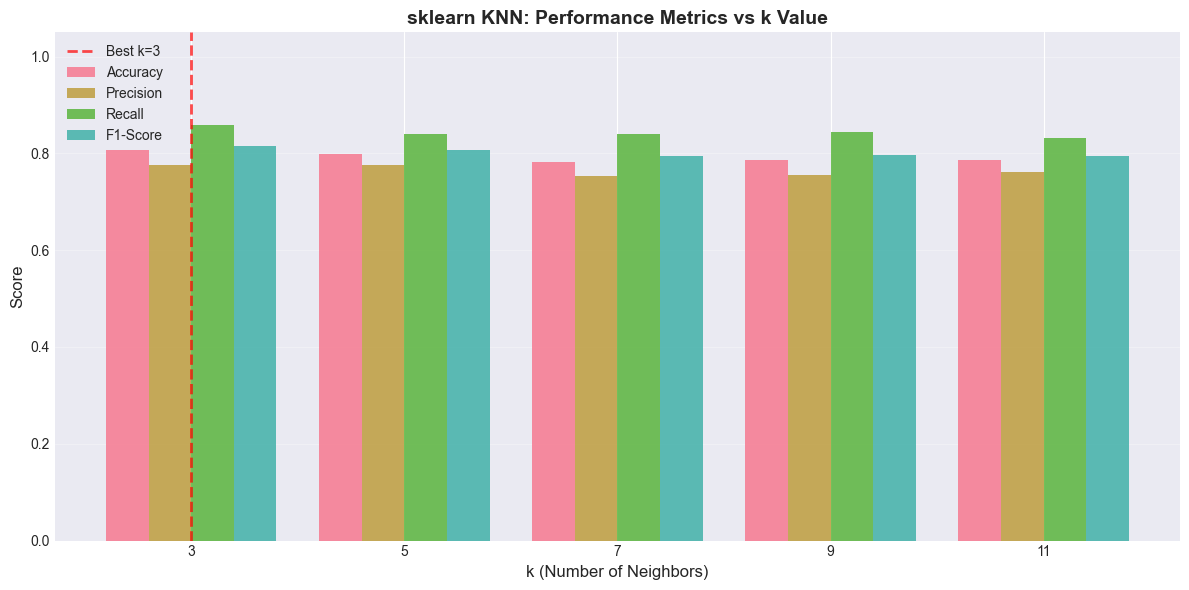


📊 Results Summary:
 k  accuracy  precision   recall  f1_score
 3  0.805936   0.776860 0.858447  0.815618
 5  0.799087   0.776371 0.840183  0.807018
 7  0.782344   0.753070 0.840183  0.794245
 9  0.785388   0.755798 0.843227  0.797122
11  0.785388   0.760779 0.832572  0.795058


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for grouped bar plot
x = np.arange(len(k_values))
width = 0.2

# Create bars for each metric
bars1 = ax.bar(x - 1.5*width, results_df['accuracy'], width, label='Accuracy', alpha=0.8)
bars2 = ax.bar(x - 0.5*width, results_df['precision'], width, label='Precision', alpha=0.8)
bars3 = ax.bar(x + 0.5*width, results_df['recall'], width, label='Recall', alpha=0.8)
bars4 = ax.bar(x + 1.5*width, results_df['f1_score'], width, label='F1-Score', alpha=0.8)

# Highlight best k
best_k_idx = results_df['f1_score'].idxmax()
ax.axvline(best_k_idx, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Best k={int(best_k)}')

ax.set_xlabel('k (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('sklearn KNN: Performance Metrics vs k Value', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(k_values)
ax.legend(loc='best')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Display results table
print("\n📊 Results Summary:")
print(results_df.to_string(index=False))

### 4.2 Confusion Matrix for Best k

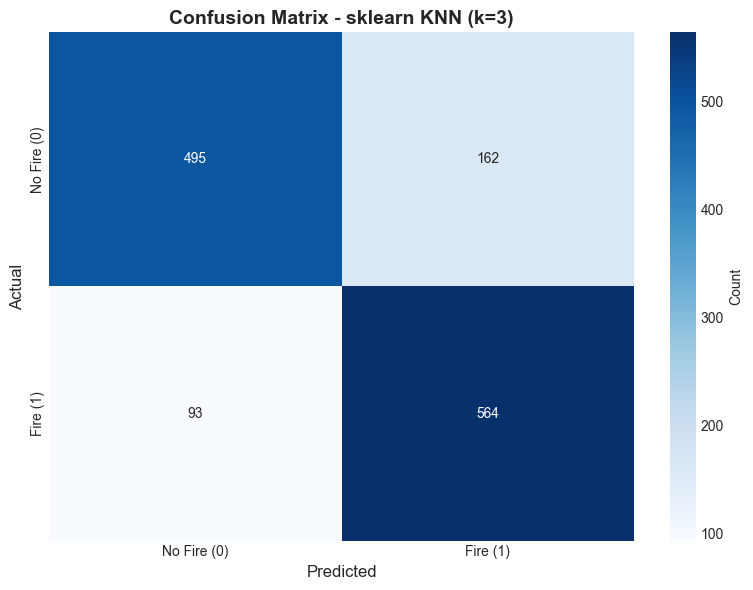


📋 Classification Report (sklearn KNN, k=3):

              precision    recall  f1-score   support

 No Fire (0)       0.84      0.75      0.80       657
    Fire (1)       0.78      0.86      0.82       657

    accuracy                           0.81      1314
   macro avg       0.81      0.81      0.81      1314
weighted avg       0.81      0.81      0.81      1314



In [6]:
# Train with best k
best_knn = KNeighborsClassifier(n_neighbors=int(best_k), metric='euclidean')
best_knn.fit(X_train_eng, y_train_eng)
y_pred_best = best_knn.predict(X_test_eng)

# Confusion matrix
cm = confusion_matrix(y_test_eng, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix - sklearn KNN (k={int(best_k)})', fontsize=14, fontweight='bold')
ax.set_xticklabels(['No Fire (0)', 'Fire (1)'])
ax.set_yticklabels(['No Fire (0)', 'Fire (1)'])
plt.tight_layout()
plt.show()

# Classification report
print("\n📋 Classification Report (sklearn KNN, k={}):\n".format(int(best_k)))
print(classification_report(y_test_eng, y_pred_best, target_names=['No Fire (0)', 'Fire (1)']))

## 5. Custom KNN Implementation Comparison

Now testing the custom KNN implementation from `models/knn.py`

### 5.1 Prepare Original Dataset

In [7]:
# Prepare original dataset
X_orig = df_original.drop(['longitude', 'latitude', 'class'], axis=1)
y_orig = df_original['class']

# Handle non-numeric columns if any
non_numeric_cols = X_orig.select_dtypes(include=['object']).columns.tolist()
if non_numeric_cols:
    print(f"⚠️  Non-numeric columns found: {non_numeric_cols}")
    print(f"   Dropping non-numeric columns...")
    X_orig = X_orig.select_dtypes(include=[np.number])

# Handle missing values
if X_orig.isnull().sum().sum() > 0:
    print(f"⚠️  Missing values detected. Filling with mean...")
    X_orig = X_orig.fillna(X_orig.mean())

# Split the data
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)

# Scale the original dataset (engineered is already scaled)
scaler = StandardScaler()
X_train_orig_scaled = scaler.fit_transform(X_train_orig)
X_test_orig_scaled = scaler.transform(X_test_orig)

print(f"Original Dataset Split:")
print(f"  Training: {X_train_orig.shape[0]} samples")
print(f"  Testing: {X_test_orig.shape[0]} samples")
print(f"  Features: {X_train_orig.shape[1]}")
print(f"  Train class distribution: {y_train_orig.value_counts().to_dict()}")
print(f"  Test class distribution: {y_test_orig.value_counts().to_dict()}")
print(f"✅ Features scaled using StandardScaler")

Original Dataset Split:
  Training: 5256 samples
  Testing: 1314 samples
  Features: 41
  Train class distribution: {0: 2628, 1: 2628}
  Test class distribution: {1: 657, 0: 657}
✅ Features scaled using StandardScaler


### 5.2 Test Custom KNN on Both Datasets

In [8]:
print("="*80)
print("CUSTOM KNN IMPLEMENTATION - DATASET COMPARISON")
print("="*80)

# Use the best k found earlier
optimal_k = int(best_k)

comparison_results = []

# Test on Original Dataset
print(f"\n{'='*80}")
print(f"Testing on ORIGINAL DATASET (k={optimal_k})")
print(f"{'='*80}")

knn_custom_orig = KNN(k=optimal_k, distance_metric='euclidean')
knn_custom_orig.fit(X_train_orig_scaled, y_train_orig.values)
y_pred_orig = knn_custom_orig.predict(X_test_orig_scaled)

acc_orig = accuracy_score(y_test_orig, y_pred_orig)
prec_orig = precision_score(y_test_orig, y_pred_orig)
rec_orig = recall_score(y_test_orig, y_pred_orig)
f1_orig = f1_score(y_test_orig, y_pred_orig)

comparison_results.append({
    'Dataset': 'Original (42 features)',
    'Model': 'Custom KNN',
    'k': optimal_k,
    'Features': X_train_orig.shape[1],
    'Accuracy': acc_orig,
    'Precision': prec_orig,
    'Recall': rec_orig,
    'F1-Score': f1_orig
})

print(f"  Features: {X_train_orig.shape[1]}")
print(f"  Accuracy:  {acc_orig:.4f}")
print(f"  Precision: {prec_orig:.4f}")
print(f"  Recall:    {rec_orig:.4f}")
print(f"  F1-Score:  {f1_orig:.4f}")

# Test on Engineered Dataset
print(f"\n{'='*80}")
print(f"Testing on ENGINEERED DATASET (k={optimal_k})")
print(f"{'='*80}")

knn_custom_eng = KNN(k=optimal_k, distance_metric='euclidean')
knn_custom_eng.fit(X_train_eng.values, y_train_eng.values)
y_pred_eng = knn_custom_eng.predict(X_test_eng.values)

acc_eng = accuracy_score(y_test_eng, y_pred_eng)
prec_eng = precision_score(y_test_eng, y_pred_eng)
rec_eng = recall_score(y_test_eng, y_pred_eng)
f1_eng = f1_score(y_test_eng, y_pred_eng)

comparison_results.append({
    'Dataset': 'Engineered (20 features)',
    'Model': 'Custom KNN',
    'k': optimal_k,
    'Features': X_train_eng.shape[1],
    'Accuracy': acc_eng,
    'Precision': prec_eng,
    'Recall': rec_eng,
    'F1-Score': f1_eng
})

print(f"  Features: {X_train_eng.shape[1]}")
print(f"  Accuracy:  {acc_eng:.4f}")
print(f"  Precision: {prec_eng:.4f}")
print(f"  Recall:    {rec_eng:.4f}")
print(f"  F1-Score:  {f1_eng:.4f}")

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_results)

print("\n" + "="*80)
print("📊 COMPARISON SUMMARY")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

CUSTOM KNN IMPLEMENTATION - DATASET COMPARISON

Testing on ORIGINAL DATASET (k=3)
  Features: 41
  Accuracy:  0.7960
  Precision: 0.7675
  Recall:    0.8493
  F1-Score:  0.8064

Testing on ENGINEERED DATASET (k=3)
  Features: 20
  Accuracy:  0.8059
  Precision: 0.7769
  Recall:    0.8584
  F1-Score:  0.8156

📊 COMPARISON SUMMARY
                 Dataset      Model  k  Features  Accuracy  Precision   Recall  F1-Score
  Original (42 features) Custom KNN  3        41  0.796043   0.767538 0.849315  0.806358
Engineered (20 features) Custom KNN  3        20  0.805936   0.776860 0.858447  0.815618


### 5.3 Visualize Dataset Comparison

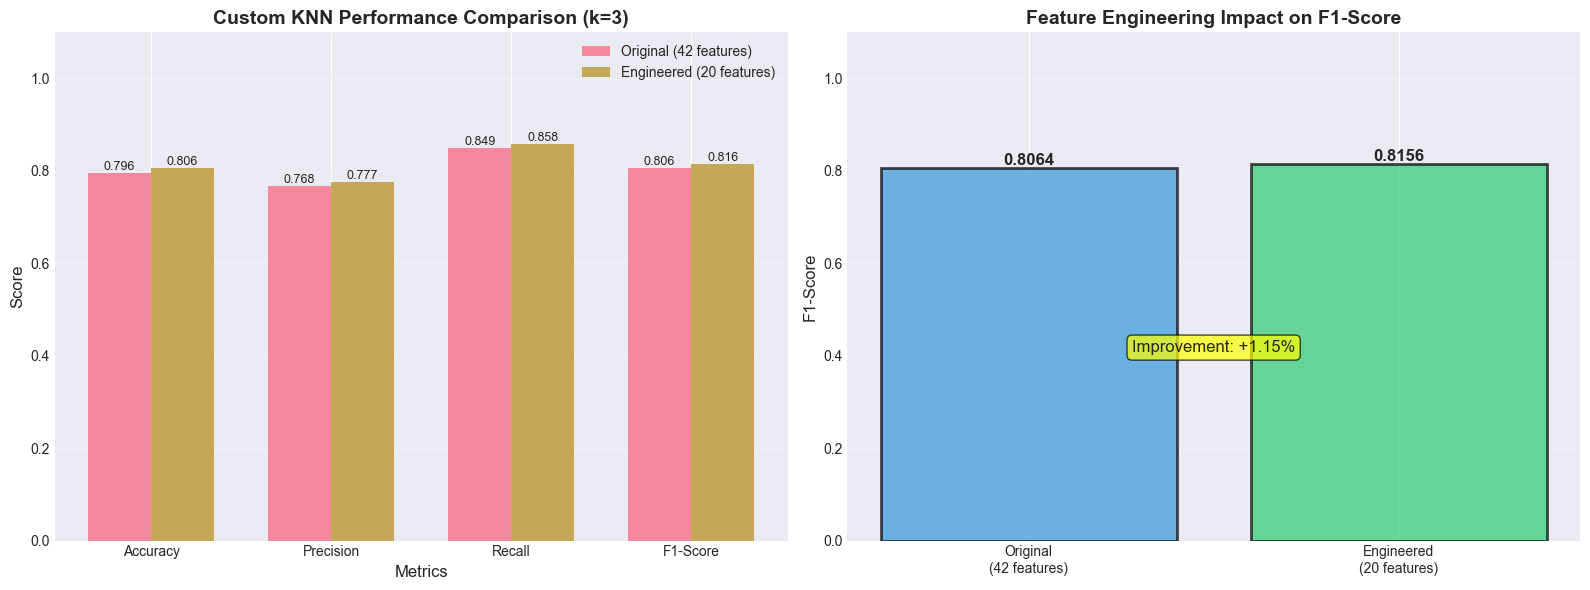

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x_pos = np.arange(len(metrics))
width = 0.35

ax = axes[0]
orig_vals = [acc_orig, prec_orig, rec_orig, f1_orig]
eng_vals = [acc_eng, prec_eng, rec_eng, f1_eng]

bars1 = ax.bar(x_pos - width/2, orig_vals, width, label='Original (42 features)', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, eng_vals, width, label='Engineered (20 features)', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Custom KNN Performance Comparison (k={optimal_k})', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Feature count vs F1-Score
ax = axes[1]
datasets = ['Original\n(42 features)', 'Engineered\n(20 features)']
f1_scores = [f1_orig, f1_eng]
colors = ['#3498db', '#2ecc71']

bars = ax.bar(datasets, f1_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Feature Engineering Impact on F1-Score', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{score:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Calculate improvement
improvement = ((f1_eng - f1_orig) / f1_orig) * 100
ax.text(0.5, max(f1_scores) * 0.5, f'Improvement: {improvement:+.2f}%',
        ha='center', fontsize=12, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

### 5.4 Confusion Matrices Comparison

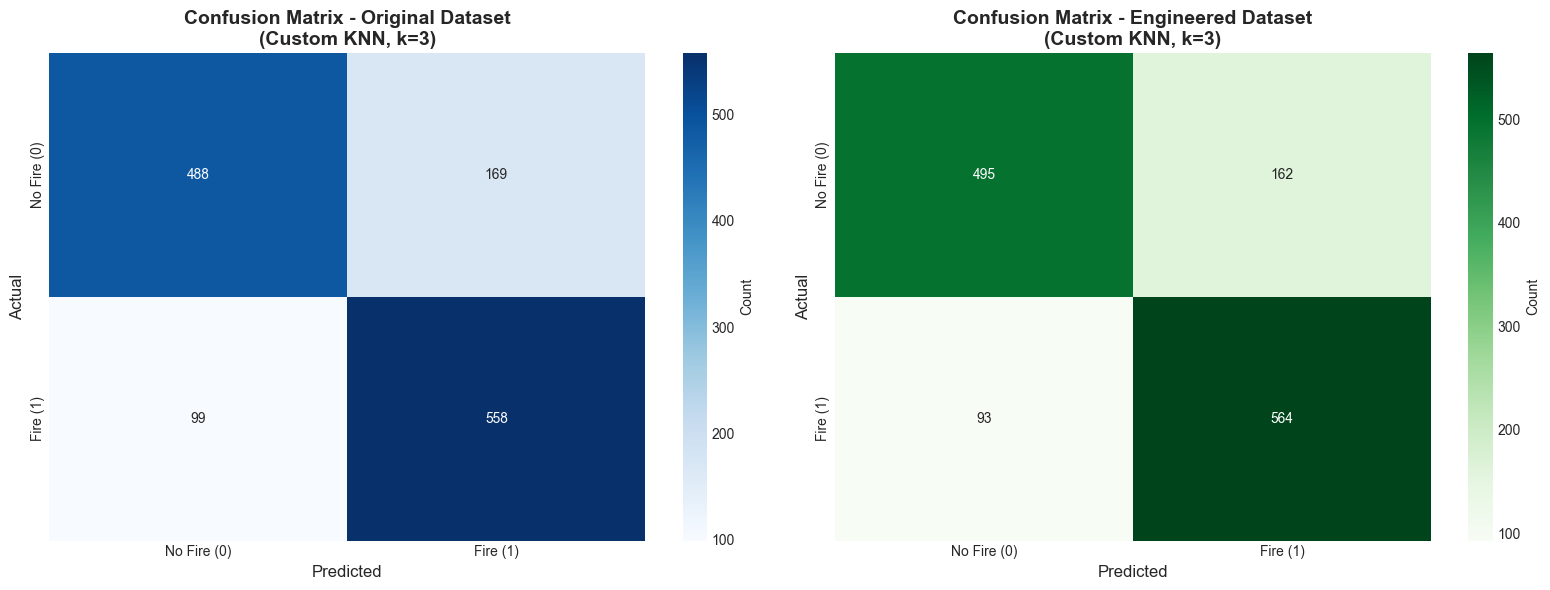

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original dataset confusion matrix
cm_orig = confusion_matrix(y_test_orig, y_pred_orig)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title(f'Confusion Matrix - Original Dataset\n(Custom KNN, k={optimal_k})', 
                  fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['No Fire (0)', 'Fire (1)'])
axes[0].set_yticklabels(['No Fire (0)', 'Fire (1)'])

# Engineered dataset confusion matrix
cm_eng = confusion_matrix(y_test_eng, y_pred_eng)
sns.heatmap(cm_eng, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title(f'Confusion Matrix - Engineered Dataset\n(Custom KNN, k={optimal_k})', 
                  fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No Fire (0)', 'Fire (1)'])
axes[1].set_yticklabels(['No Fire (0)', 'Fire (1)'])

plt.tight_layout()
plt.show()

## 6. Final Summary & Conclusions

In [11]:
print("="*80)
print("FINAL SUMMARY - K-NEAREST NEIGHBORS ANALYSIS")
print("="*80)

print("\n🔍 OPTIMAL K VALUE (sklearn KNN):")
print(f"   Best k: {int(best_k)}")
print(f"   F1-Score: {best_f1:.4f}")

print("\n📊 CUSTOM KNN IMPLEMENTATION RESULTS:")
print("\n" + comparison_df.to_string(index=False))

print("\n📈 FEATURE ENGINEERING IMPACT:")
improvement_acc = ((acc_eng - acc_orig) / acc_orig) * 100
improvement_f1 = ((f1_eng - f1_orig) / f1_orig) * 100
print(f"   Accuracy improvement:  {improvement_acc:+.2f}%")
print(f"   F1-Score improvement:  {improvement_f1:+.2f}%")
print(f"   Feature reduction: {X_train_orig.shape[1]} → {X_train_eng.shape[1]} features ({(1 - X_train_eng.shape[1]/X_train_orig.shape[1])*100:.1f}% reduction)")

print("\n💡 KEY FINDINGS:")
if f1_eng > f1_orig:
    print(f"   ✅ Engineered features show BETTER performance")
    print(f"   ✅ Feature engineering successfully improved model accuracy")
    print(f"   ✅ Reduced feature space leads to faster predictions")
else:
    print(f"   ⚠️  Original features perform better")
    print(f"   ⚠️  Feature engineering may need refinement")

print(f"\n🎯 BEST CONFIGURATION:")
print(f"   Model: Custom KNN")
print(f"   k value: {optimal_k}")
if f1_eng > f1_orig:
    print(f"   Dataset: Engineered (20 features)")
    print(f"   F1-Score: {f1_eng:.4f}")
else:
    print(f"   Dataset: Original (42 features)")
    print(f"   F1-Score: {f1_orig:.4f}")

print("\n" + "="*80)
print("✅ KNN ANALYSIS COMPLETE!")
print("="*80)

FINAL SUMMARY - K-NEAREST NEIGHBORS ANALYSIS

🔍 OPTIMAL K VALUE (sklearn KNN):
   Best k: 3
   F1-Score: 0.8156

📊 CUSTOM KNN IMPLEMENTATION RESULTS:

                 Dataset      Model  k  Features  Accuracy  Precision   Recall  F1-Score
  Original (42 features) Custom KNN  3        41  0.796043   0.767538 0.849315  0.806358
Engineered (20 features) Custom KNN  3        20  0.805936   0.776860 0.858447  0.815618

📈 FEATURE ENGINEERING IMPACT:
   Accuracy improvement:  +1.24%
   F1-Score improvement:  +1.15%
   Feature reduction: 41 → 20 features (51.2% reduction)

💡 KEY FINDINGS:
   ✅ Engineered features show BETTER performance
   ✅ Feature engineering successfully improved model accuracy
   ✅ Reduced feature space leads to faster predictions

🎯 BEST CONFIGURATION:
   Model: Custom KNN
   k value: 3
   Dataset: Engineered (20 features)
   F1-Score: 0.8156

✅ KNN ANALYSIS COMPLETE!
